# **FINAL MODEL**

TRAIN/TEST split

In [1]:
import os
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


Device: cpu


In [3]:
GROUND_VIEW_1 = "/kaggle/input/kitti-360-0000/KITTI-360/data_2d_raw/2013_05_28_drive_0000_sync/image_00/data_rect"
GROUND_VIEW_2 = "/kaggle/input/kitti-500-samples/kitti-360-image_01/kitti-360-image_01"
GROUND_VIEW_3 = "/kaggle/input/kitti-500-samples/kitti-360-image_02/kitti-360-image_02"
GROUND_VIEW_4 = "/kaggle/input/kitti-500-samples/kitti-360-image_03.zip/kitti-360-image_03.zip"

SAT_ROOT = "/kaggle/input/satellite-view-kitti"
INDEX_FILE = f"{SAT_ROOT}/location_names.txt"
print("load data")

load data


In [4]:
def load_locations(index_file):
    locations = {}
    with open(index_file, "r") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) < 2:
                continue

            idx = int(parts[0]) - 1  # make 0-based
            lat, lon = map(float, parts[1].split(","))
            locations[idx] = (lat, lon)

    return locations

locations = load_locations(INDEX_FILE)
print("Loaded locations:", len(locations))
print("Example:", list(locations.items())[:3])


Loaded locations: 500
Example: [(0, (49.01779795478, 8.4411710247314)), (1, (49.01779797818, 8.4411710209436)), (2, (49.017798042111, 8.4411710439312))]


In [5]:
def build_samples():
    samples = []

    ground_files = sorted(os.listdir(GROUND_VIEW_1))

    for fname in ground_files:
        if not fname.endswith(".png"):
            continue

        idx = int(fname.replace(".png", ""))

        if idx not in locations:
            continue

        v1 = os.path.join(GROUND_VIEW_1, fname)
        v2 = os.path.join(GROUND_VIEW_2, fname)
        v3 = os.path.join(GROUND_VIEW_3, fname)
        v4 = os.path.join(GROUND_VIEW_4, fname)

        sat_name = f"satellite_{idx+1:03d}.png"
        sat_path = os.path.join(SAT_ROOT, sat_name)

        if not (os.path.exists(v1) and os.path.exists(v2) and os.path.exists(v3) and os.path.exists(v4)):
            continue

        if not os.path.exists(sat_path):
            continue

        samples.append({
            "views": [v1, v2, v3, v4],
            "sat": sat_path,
            "latlon": locations[idx],
            "idx": idx
        })

    return samples

samples = build_samples()
print("Total valid samples:", len(samples))
print("Example sample:", samples[0])


Total valid samples: 500
Example sample: {'views': ['/kaggle/input/kitti-360-0000/KITTI-360/data_2d_raw/2013_05_28_drive_0000_sync/image_00/data_rect/0000000000.png', '/kaggle/input/kitti-500-samples/kitti-360-image_01/kitti-360-image_01/0000000000.png', '/kaggle/input/kitti-500-samples/kitti-360-image_02/kitti-360-image_02/0000000000.png', '/kaggle/input/kitti-500-samples/kitti-360-image_03.zip/kitti-360-image_03.zip/0000000000.png'], 'sat': '/kaggle/input/satellite-view-kitti/satellite_001.png', 'latlon': (49.01779795478, 8.4411710247314), 'idx': 0}


Index: 0
Lat/Lon: (49.01779795478, 8.4411710247314)
Views: ['/kaggle/input/kitti-360-0000/KITTI-360/data_2d_raw/2013_05_28_drive_0000_sync/image_00/data_rect/0000000000.png', '/kaggle/input/kitti-500-samples/kitti-360-image_01/kitti-360-image_01/0000000000.png', '/kaggle/input/kitti-500-samples/kitti-360-image_02/kitti-360-image_02/0000000000.png', '/kaggle/input/kitti-500-samples/kitti-360-image_03.zip/kitti-360-image_03.zip/0000000000.png']
Satellite: /kaggle/input/satellite-view-kitti/satellite_001.png


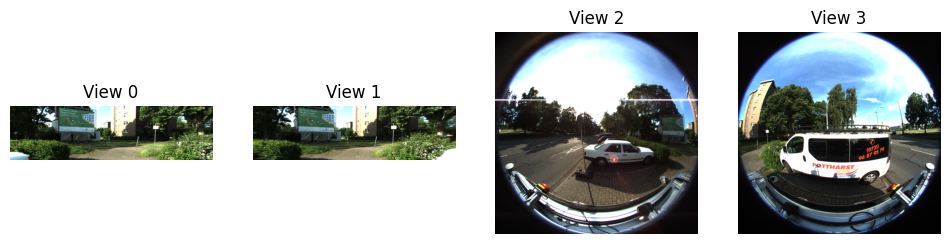

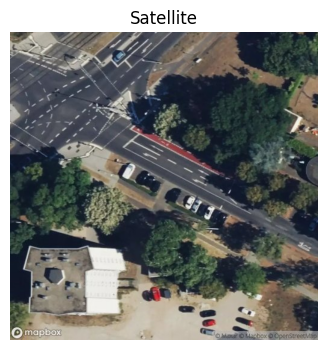

In [6]:
s = samples[0]

print("Index:", s["idx"])
print("Lat/Lon:", s["latlon"])
print("Views:", s["views"])
print("Satellite:", s["sat"])

plt.figure(figsize=(12,3))
for i,p in enumerate(s["views"]):
    img = Image.open(p).convert("RGB")
    plt.subplot(1,4,i+1)
    plt.imshow(img)
    plt.title(f"View {i}")
    plt.axis("off")
plt.show()

plt.figure(figsize=(4,4))
plt.imshow(Image.open(s["sat"]).convert("RGB"))
plt.title("Satellite")
plt.axis("off")
plt.show()


In [7]:
all_lats = [s["latlon"][0] for s in samples]
all_lons = [s["latlon"][1] for s in samples]

LAT_MIN, LAT_MAX = min(all_lats), max(all_lats)
LON_MIN, LON_MAX = min(all_lons), max(all_lons)

print("Lat range:", LAT_MIN, LAT_MAX)
print("Lon range:", LON_MIN, LON_MAX)

def normalize_latlon(latlon):
    lat, lon = latlon
    lat_n = (lat - LAT_MIN) / (LAT_MAX - LAT_MIN + 1e-8)
    lon_n = (lon - LON_MIN) / (LON_MAX - LON_MIN + 1e-8)
    return torch.tensor([lat_n, lon_n], dtype=torch.float)

def denormalize_latlon(x):
    lat = x[:, 0] * (LAT_MAX - LAT_MIN) + LAT_MIN
    lon = x[:, 1] * (LON_MAX - LON_MIN) + LON_MIN
    return torch.stack([lat, lon], dim=1)

def haversine(pred, gt):
    R = 6371000

    lat1, lon1 = pred[:, 0], pred[:, 1]
    lat2, lon2 = gt[:, 0], gt[:, 1]

    phi1 = torch.deg2rad(lat1)
    phi2 = torch.deg2rad(lat2)

    dphi = torch.deg2rad(lat2 - lat1)
    dl = torch.deg2rad(lon2 - lon1)

    a = torch.sin(dphi/2)**2 + torch.cos(phi1)*torch.cos(phi2)*torch.sin(dl/2)**2
    return 2 * R * torch.atan2(torch.sqrt(a), torch.sqrt(1-a))


Lat range: 49.017576164936 49.018856170895
Lon range: 8.4411422617245 8.4438062694374


In [8]:
class KITTIMultiViewDatasetA(Dataset):
    def __init__(self, samples, transform):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]

        views = []
        for p in s["views"]:
            img = Image.open(p).convert("RGB")
            views.append(self.transform(img))
        views = torch.stack(views)

        sat = self.transform(Image.open(s["sat"]).convert("RGB"))

        latlon = normalize_latlon(s["latlon"])

        return views, sat, latlon


In [9]:
random.shuffle(samples)

split = int(0.8 * len(samples))
train_samples = samples[:split]
test_samples  = samples[split:]

print("Train:", len(train_samples), "Test:", len(test_samples))

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_ds = KITTIMultiViewDatasetA(train_samples, transform)
test_ds  = KITTIMultiViewDatasetA(test_samples, transform)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=1, shuffle=False)


Train: 400 Test: 100


In [10]:
class Encoder(nn.Module):
    def __init__(self, out_dim=512):
        super().__init__()
        backbone = models.resnet18(weights=None)
        self.features = nn.Sequential(*list(backbone.children())[:-1])
        self.fc = nn.Linear(512, out_dim)

    def forward(self, x):
        x = self.features(x).flatten(1)
        return self.fc(x)

class ViewFusion(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.Linear(dim, 1)

    def forward(self, x):
        w = torch.softmax(self.attn(x), dim=1)
        fused = (w * x).sum(dim=1)
        return fused, w


In [11]:
class ModelA(nn.Module):
    def __init__(self):
        super().__init__()
        self.g_enc = Encoder(512)
        self.s_enc = Encoder(512)
        self.fusion = ViewFusion(512)

        self.regressor = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 2)
        )

    def forward(self, views, sat):
        B, V, C, H, W = views.shape

        gv = views.view(B*V, C, H, W)
        gv_feat = self.g_enc(gv).view(B, V, -1)

        fused, weights = self.fusion(gv_feat)

        # (sat_feat not used explicitly, but kept for cross-view possibility)
        sat_feat = self.s_enc(sat)

        pred = self.regressor(fused)

        return pred, weights


In [12]:
model_A = ModelA().to(device)
optimizer_A = torch.optim.Adam(model_A.parameters(), lr=1e-4)

EPOCHS_A = 5

loss_history_A = []

for epoch in range(EPOCHS_A):
    model_A.train()
    total_loss = 0

    for views, sat, gt in train_loader:
        views, sat, gt = views.to(device), sat.to(device), gt.to(device)

        pred, _ = model_A(views, sat)

        loss = F.mse_loss(pred, gt)

        optimizer_A.zero_grad()
        loss.backward()
        optimizer_A.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_history_A.append(avg_loss)

    print(f"[Model A] Epoch {epoch+1}/{EPOCHS_A} | Loss: {avg_loss:.4f}")


[Model A] Epoch 1/5 | Loss: 0.0684
[Model A] Epoch 2/5 | Loss: 0.0185
[Model A] Epoch 3/5 | Loss: 0.0079
[Model A] Epoch 4/5 | Loss: 0.0053
[Model A] Epoch 5/5 | Loss: 0.0024


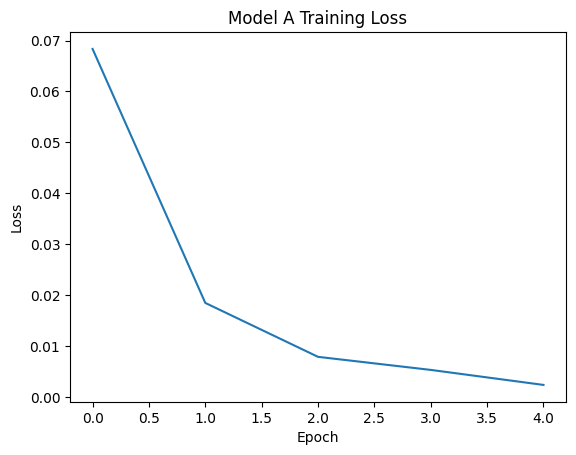

In [13]:
plt.figure()
plt.plot(loss_history_A)
plt.title("Model A Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


In [14]:
model_A.eval()
errors_A = []

with torch.no_grad():
    for views, sat, gt in test_loader:
        views, sat, gt = views.to(device), sat.to(device), gt.to(device)

        pred, _ = model_A(views, sat)

        pred_latlon = denormalize_latlon(pred.cpu())
        gt_latlon   = denormalize_latlon(gt.cpu())

        err = haversine(pred_latlon, gt_latlon)
        errors_A.append(err.item())

print("Model A Mean error (m):", np.mean(errors_A))
print("Model A Median error (m):", np.median(errors_A))
print("Model A Min error (m):", np.min(errors_A))
print("Model A Max error (m):", np.max(errors_A))


Model A Mean error (m): 8.559279241561889
Model A Median error (m): 5.78098464012146
Model A Min error (m): 1.1900322437286377
Model A Max error (m): 31.504316329956055


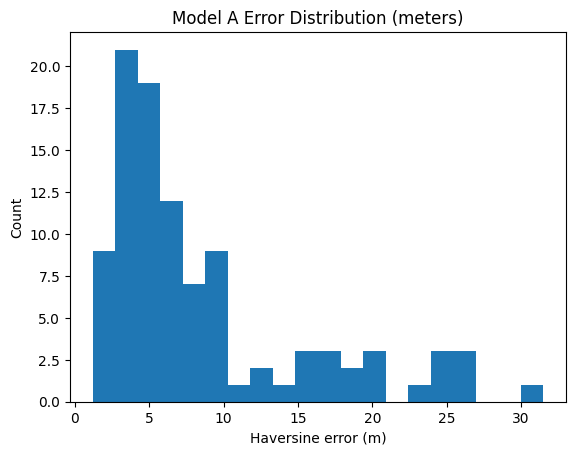

In [15]:
plt.figure()
plt.hist(errors_A, bins=20)
plt.title("Model A Error Distribution (meters)")
plt.xlabel("Haversine error (m)")
plt.ylabel("Count")
plt.show()


===== Model A Inference =====
GT lat/lon   : [49.01780700683594, 8.441174507141113]
Pred lat/lon : [49.01778030395508, 8.44111442565918]
Error (m)    : 5.292730808258057


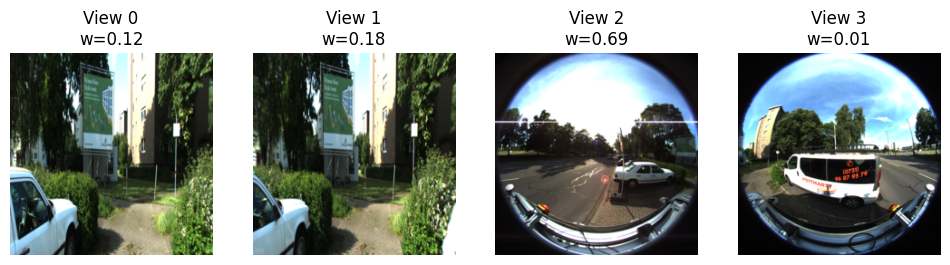

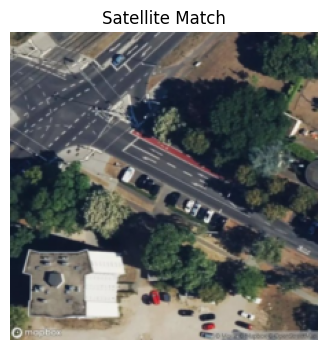

In [16]:
idx = 0

views, sat, gt = test_ds[idx]

views_batch = views.unsqueeze(0).to(device)
sat_batch   = sat.unsqueeze(0).to(device)
gt_batch    = gt.unsqueeze(0)

model_A.eval()

with torch.no_grad():
    pred, weights = model_A(views_batch, sat_batch)

pred_latlon = denormalize_latlon(pred.cpu())
gt_latlon   = denormalize_latlon(gt_batch)

err = haversine(pred_latlon, gt_latlon).item()

weights = weights.squeeze().cpu().numpy()

print("===== Model A Inference =====")
print("GT lat/lon   :", gt_latlon[0].tolist())
print("Pred lat/lon :", pred_latlon[0].tolist())
print("Error (m)    :", err)

plt.figure(figsize=(12,3))
for i in range(4):
    plt.subplot(1,4,i+1)
    plt.imshow(views[i].permute(1,2,0))
    plt.title(f"View {i}\nw={weights[i]:.2f}")
    plt.axis("off")
plt.show()

plt.figure(figsize=(4,4))
plt.imshow(sat.permute(1,2,0))
plt.title("Satellite Match")
plt.axis("off")
plt.show()


# ** ORIENTATION AWARE RETRIEVAL**

In [17]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


Device: cpu


In [19]:
GROUND_VIEW_1 = "/kaggle/input/kitti-360-0000/KITTI-360/data_2d_raw/2013_05_28_drive_0000_sync/image_00/data_rect"
GROUND_VIEW_2 = "/kaggle/input/kitti-500-samples/kitti-360-image_01/kitti-360-image_01"
GROUND_VIEW_3 = "/kaggle/input/kitti-500-samples/kitti-360-image_02/kitti-360-image_02"
GROUND_VIEW_4 = "/kaggle/input/kitti-500-samples/kitti-360-image_03.zip/kitti-360-image_03.zip"

SAT_ROOT = "/kaggle/input/satellite-view-kitti"
INDEX_FILE = f"{SAT_ROOT}/location_names.txt"


In [20]:
def load_locations(index_file):
    loc = {}
    with open(index_file, "r") as f:
        for line in f:
            parts = line.strip().split("\t")
            idx = int(parts[0]) - 1
            lat, lon = map(float, parts[1].split(","))
            loc[idx] = (lat, lon)
    return loc

locations = load_locations(INDEX_FILE)
print("Loaded locations:", len(locations))


Loaded locations: 500


In [21]:
def build_samples():
    samples = []
    files = sorted(os.listdir(GROUND_VIEW_1))

    for f in files:
        if not f.endswith(".png"):
            continue

        idx = int(f.replace(".png", ""))
        if idx not in locations:
            continue

        views = [
            os.path.join(GROUND_VIEW_1, f),
            os.path.join(GROUND_VIEW_2, f),
            os.path.join(GROUND_VIEW_3, f),
            os.path.join(GROUND_VIEW_4, f),
        ]

        sat = os.path.join(SAT_ROOT, f"satellite_{idx+1:03d}.png")

        if not all(os.path.exists(p) for p in views + [sat]):
            continue

        samples.append({
            "views": views,
            "sat": sat,
            "latlon": locations[idx],
            "idx": idx
        })

    return samples

samples = build_samples()
print("Total usable samples:", len(samples))
print("Example sample:", samples[0])


Total usable samples: 500
Example sample: {'views': ['/kaggle/input/kitti-360-0000/KITTI-360/data_2d_raw/2013_05_28_drive_0000_sync/image_00/data_rect/0000000000.png', '/kaggle/input/kitti-500-samples/kitti-360-image_01/kitti-360-image_01/0000000000.png', '/kaggle/input/kitti-500-samples/kitti-360-image_02/kitti-360-image_02/0000000000.png', '/kaggle/input/kitti-500-samples/kitti-360-image_03.zip/kitti-360-image_03.zip/0000000000.png'], 'sat': '/kaggle/input/satellite-view-kitti/satellite_001.png', 'latlon': (49.01779795478, 8.4411710247314), 'idx': 0}


In [22]:
print("GROUND_VIEW_1 exists:", os.path.exists(GROUND_VIEW_1))
print("GROUND_VIEW_2 exists:", os.path.exists(GROUND_VIEW_2))
print("GROUND_VIEW_3 exists:", os.path.exists(GROUND_VIEW_3))
print("GROUND_VIEW_4 exists:", os.path.exists(GROUND_VIEW_4))
print("SAT_ROOT exists:", os.path.exists(SAT_ROOT))

print("\nSample files in View1:", sorted(os.listdir(GROUND_VIEW_1))[:5])
print("Sample files in View2:", sorted(os.listdir(GROUND_VIEW_2))[:5])
print("Sample files in View3:", sorted(os.listdir(GROUND_VIEW_3))[:5])
print("Sample files in View4:", sorted(os.listdir(GROUND_VIEW_4))[:5])

print("\nSample satellite files:", sorted(os.listdir(SAT_ROOT))[:10])


GROUND_VIEW_1 exists: True
GROUND_VIEW_2 exists: True
GROUND_VIEW_3 exists: True
GROUND_VIEW_4 exists: True
SAT_ROOT exists: True

Sample files in View1: ['0000000000.png', '0000000001.png', '0000000002.png', '0000000003.png', '0000000004.png']
Sample files in View2: ['0000000000.png', '0000000001.png', '0000000002.png', '0000000003.png', '0000000004.png']
Sample files in View3: ['0000000000.png', '0000000001.png', '0000000002.png', '0000000003.png', '0000000004.png']
Sample files in View4: ['0000000000.png', '0000000001.png', '0000000002.png', '0000000003.png', '0000000004.png']

Sample satellite files: ['location_names.txt', 'satellite_001.png', 'satellite_002.png', 'satellite_003.png', 'satellite_004.png', 'satellite_005.png', 'satellite_006.png', 'satellite_007.png', 'satellite_008.png', 'satellite_009.png']


In [23]:
lats = [s["latlon"][0] for s in samples]
lons = [s["latlon"][1] for s in samples]

LAT_MIN, LAT_MAX = min(lats), max(lats)
LON_MIN, LON_MAX = min(lons), max(lons)

print("Lat range:", LAT_MIN, LAT_MAX)
print("Lon range:", LON_MIN, LON_MAX)

def normalize_latlon(latlon):
    lat, lon = latlon
    return torch.tensor([
        (lat - LAT_MIN) / (LAT_MAX - LAT_MIN + 1e-8),
        (lon - LON_MIN) / (LON_MAX - LON_MIN + 1e-8)
    ], dtype=torch.float)

def denormalize_latlon(x):
    lat = x[:,0] * (LAT_MAX - LAT_MIN) + LAT_MIN
    lon = x[:,1] * (LON_MAX - LON_MIN) + LON_MIN
    return torch.stack([lat, lon], dim=1)

def haversine(pred, gt):
    R = 6371000
    lat1, lon1 = pred[:,0], pred[:,1]
    lat2, lon2 = gt[:,0], gt[:,1]

    phi1, phi2 = torch.deg2rad(lat1), torch.deg2rad(lat2)
    dphi = torch.deg2rad(lat2 - lat1)
    dl = torch.deg2rad(lon2 - lon1)

    a = torch.sin(dphi/2)**2 + torch.cos(phi1)*torch.cos(phi2)*torch.sin(dl/2)**2
    return 2*R*torch.atan2(torch.sqrt(a), torch.sqrt(1-a))


Lat range: 49.017576164936 49.018856170895
Lon range: 8.4411422617245 8.4438062694374


In [24]:
class KITTIMultiViewDatasetB(Dataset):
    def __init__(self, samples, transform):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]

        views = []
        for p in s["views"]:
            views.append(self.transform(Image.open(p).convert("RGB")))
        views = torch.stack(views)  # [4,3,224,224]

        sat = self.transform(Image.open(s["sat"]).convert("RGB"))
        latlon = normalize_latlon(s["latlon"])

        return views, sat, latlon


In [25]:
random.shuffle(samples)
split = int(0.8 * len(samples))

train_samples = samples[:split]
test_samples  = samples[split:]

print("Train samples:", len(train_samples))
print("Test samples :", len(test_samples))

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_ds_B = KITTIMultiViewDatasetB(train_samples, transform)
test_ds_B  = KITTIMultiViewDatasetB(test_samples, transform)

train_loader_B = DataLoader(train_ds_B, batch_size=8, shuffle=True)
test_loader_B  = DataLoader(test_ds_B, batch_size=1, shuffle=False)


Train samples: 400
Test samples : 100


In [26]:
def rotate_tensor(img, angle):
    if angle == 0:
        return img
    elif angle == 90:
        return torch.rot90(img, k=1, dims=(2,3))
    elif angle == 180:
        return torch.rot90(img, k=2, dims=(2,3))
    elif angle == 270:
        return torch.rot90(img, k=3, dims=(2,3))
    else:
        raise ValueError("Angle must be 0, 90, 180, or 270")


In [27]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.resnet18(weights=None)
        self.backbone = nn.Sequential(*list(base.children())[:-1])

    def forward(self, x):
        return self.backbone(x).flatten(1)

class ViewFusion(nn.Module):
    def __init__(self, dim=512):
        super().__init__()
        self.attn = nn.Linear(dim, 1)

    def forward(self, x):
        weights = torch.softmax(self.attn(x), dim=1)  # [B,4,1]
        fused = (weights * x).sum(dim=1)              # [B,512]
        return fused, weights


In [28]:
class ModelB_Oriented(nn.Module):
    def __init__(self):
        super().__init__()

        self.g_enc = Encoder()
        self.s_enc = Encoder()
        self.fusion = ViewFusion(512)

        self.latlon_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 2)
        )

    def forward(self, views, sat):
        B,V,C,H,W = views.shape

        # Encode all ground views
        gv = views.view(B*V, C, H, W)
        gv_feat = self.g_enc(gv).view(B, V, -1)

        # Fuse ground embeddings
        fused, weights = self.fusion(gv_feat)  # [B,512]

        # Rotate satellite images
        sat0   = sat
        sat90  = rotate_tensor(sat, 90)
        sat180 = rotate_tensor(sat, 180)
        sat270 = rotate_tensor(sat, 270)

        # Encode each rotated satellite
        s0   = self.s_enc(sat0)
        s90  = self.s_enc(sat90)
        s180 = self.s_enc(sat180)
        s270 = self.s_enc(sat270)

        sat_embs = torch.stack([s0, s90, s180, s270], dim=1)  # [B,4,512]

        # Similarity computation
        fused_n = F.normalize(fused, dim=1)
        sat_embs_n = F.normalize(sat_embs, dim=2)

        sims = torch.sum(sat_embs_n * fused_n.unsqueeze(1), dim=2)  # [B,4]
        theta_pred = torch.argmax(sims, dim=1)  # [B]

        # Predict lat/lon
        latlon_pred = self.latlon_head(fused)

        return fused, sat_embs, sims, theta_pred, latlon_pred, weights


In [29]:
def oriented_retrieval_loss(fused, sat_embs, temperature=0.07):
    fused = F.normalize(fused, dim=1)
    sat_embs = F.normalize(sat_embs, dim=2)

    # find best rotation per sample
    sims = torch.sum(sat_embs * fused.unsqueeze(1), dim=2)  # [B,4]
    best_sim, best_rot = torch.max(sims, dim=1)             # [B]

    best_sat = sat_embs[torch.arange(len(fused)), best_rot] # [B,512]

    logits = (fused @ best_sat.T) / temperature
    labels = torch.arange(len(fused)).to(fused.device)

    return F.cross_entropy(logits, labels), best_rot


In [32]:
from tqdm import tqdm
import torch.nn.functional as F

model_B = ModelB_Oriented().to(device)
optimizer_B = torch.optim.Adam(model_B.parameters(), lr=1e-4)

EPOCHS_B = 15
loss_history_B = []

LAMBDA_GPS = 1.0
LAMBDA_RET = 1.0

for epoch in range(EPOCHS_B):
    model_B.train()
    total_loss = 0.0

    # Progress bar for batches
    batch_bar = tqdm(
        train_loader_B,
        desc=f"Epoch {epoch+1}/{EPOCHS_B}",
        total=len(train_loader_B),
        leave=True
    )

    for batch_idx, (views, sat, latlon_gt) in enumerate(batch_bar, start=1):
        views = views.to(device)
        sat = sat.to(device)
        latlon_gt = latlon_gt.to(device)

        fused, sat_embs, sims, theta_pred, latlon_pred, weights = model_B(views, sat)

        loss_gps = F.mse_loss(latlon_pred, latlon_gt)
        loss_ret, theta_gt = oriented_retrieval_loss(fused, sat_embs)

        loss = (LAMBDA_GPS * loss_gps) + (LAMBDA_RET * loss_ret)

        optimizer_B.zero_grad()
        loss.backward()
        optimizer_B.step()

        total_loss += loss.item()

        # 🔹 Update progress bar text
        batch_bar.set_postfix({
            "Batch": f"{batch_idx}/{len(train_loader_B)}",
            "Loss": f"{loss.item():.4f}",
            "GPS": f"{loss_gps.item():.4f}",
            "RET": f"{loss_ret.item():.4f}"
        })

    avg_loss = total_loss / len(train_loader_B)
    loss_history_B.append(avg_loss)

    print(f"✅ Epoch {epoch+1}/{EPOCHS_B} completed | Avg Loss: {avg_loss:.4f}")


Epoch 1/15: 100%|██████████| 50/50 [07:48<00:00,  9.38s/it, Batch=50/50, Loss=1.3590, GPS=0.0172, RET=1.3419]


✅ Epoch 1/15 completed | Avg Loss: 1.4883


Epoch 2/15: 100%|██████████| 50/50 [07:50<00:00,  9.41s/it, Batch=50/50, Loss=0.6929, GPS=0.0187, RET=0.6742]


✅ Epoch 2/15 completed | Avg Loss: 1.0572


Epoch 3/15: 100%|██████████| 50/50 [07:49<00:00,  9.38s/it, Batch=50/50, Loss=0.7537, GPS=0.0204, RET=0.7333]


...

✅ Epoch 13/15 completed | Avg Loss: 0.3075


Epoch 14/15: 100%|██████████| 50/50 [08:00<00:00,  9.61s/it, Batch=50/50, Loss=0.1828, GPS=0.0149, RET=0.1679]


✅ Epoch 14/15 completed | Avg Loss: 0.2864


Epoch 15/15: 100%|██████████| 50/50 [07:56<00:00,  9.53s/it, Batch=50/50, Loss=0.1377, GPS=0.0104, RET=0.1273]

✅ Epoch 15/15 completed | Avg Loss: 0.2948


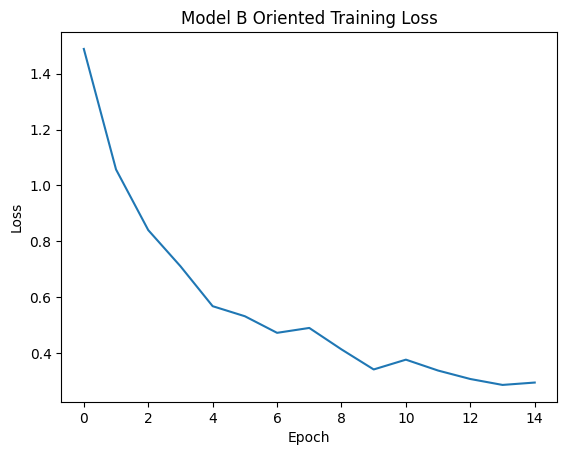

In [34]:
plt.figure()
plt.plot(loss_history_B)
plt.title("Model B Oriented Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


In [35]:
model_B.eval()
errors_B = []

with torch.no_grad():
    for views, sat, latlon_gt in test_loader_B:
        views = views.to(device)
        sat = sat.to(device)
        latlon_gt = latlon_gt.to(device)

        _, _, _, _, pred, _ = model_B(views, sat)

        pred_latlon = denormalize_latlon(pred.cpu())
        gt_latlon   = denormalize_latlon(latlon_gt.cpu())

        err = haversine(pred_latlon, gt_latlon)
        errors_B.append(err.item())

print("Model B Mean error (m):", np.mean(errors_B))
print("Model B Median error (m):", np.median(errors_B))
print("Model B Min error (m):", np.min(errors_B))
print("Model B Max error (m):", np.max(errors_B))


Model B Mean error (m): 27.24470310330391
Model B Median error (m): 18.021559715270996
Model B Min error (m): 1.6548501253128052
Model B Max error (m): 112.33892059326172


In [36]:
def build_sat_gallery_oriented(model, dataset):
    model.eval()
    sat_embs = []
    sat_paths = []

    with torch.no_grad():
        for i in range(len(dataset)):
            _, sat, _ = dataset[i]
            sat = sat.unsqueeze(0).to(device)

            # Encode satellite at 0 degrees (gallery reference)
            emb = model.s_enc(sat)
            emb = F.normalize(emb, dim=1)

            sat_embs.append(emb.cpu())
            sat_paths.append(dataset.samples[i]["sat"])

    sat_embs = torch.cat(sat_embs, dim=0)  # [N,512]
    return sat_embs, sat_paths

sat_gallery_emb, sat_gallery_paths = build_sat_gallery_oriented(model_B, test_ds_B)
print("Gallery embeddings:", sat_gallery_emb.shape)


Gallery embeddings: torch.Size([100, 512])


In [37]:
def compute_recall_at_k_oriented(model, dataset, sat_gallery_emb, k_list=[1,5]):
    model.eval()
    correct = {k: 0 for k in k_list}
    total = len(dataset)

    with torch.no_grad():
        for i in range(total):
            views, sat, _ = dataset[i]

            views = views.unsqueeze(0).to(device)
            sat = sat.unsqueeze(0).to(device)

            fused, sat_embs, sims, theta_pred, _, _ = model(views, sat)

            fused = F.normalize(fused.cpu(), dim=1)

            # Compare fused embedding to gallery embeddings
            sim_scores = fused @ sat_gallery_emb.T  # [1,N]

            ranked = torch.argsort(sim_scores, dim=1, descending=True).squeeze(0)

            for k in k_list:
                if i in ranked[:k].tolist():
                    correct[k] += 1

    recalls = {k: correct[k] / total for k in k_list}
    return recalls

recalls = compute_recall_at_k_oriented(model_B, test_ds_B, sat_gallery_emb, k_list=[1,5])


In [38]:
recalls = compute_recall_at_k_oriented(
    model_B,
    test_ds_B,
    sat_gallery_emb,
    k_list=[1, 5, 10]
)

print("===== Retrieval Recall =====")
print(f"Recall@1 : {recalls[1]*100:.2f}%")
print(f"Recall@5 : {recalls[5]*100:.2f}%")
print(f"Recall@10: {recalls[10]*100:.2f}%")


===== Retrieval Recall =====
Recall@1 : 9.00%
Recall@5 : 30.00%
Recall@10: 59.00%


In [39]:
theta_map = {0: 0, 1: 90, 2: 180, 3: 270}
TOP_K = 5
idx = 0

views, sat, latlon_gt = test_ds_B[idx]

views_batch = views.unsqueeze(0).to(device)
sat_batch   = sat.unsqueeze(0).to(device)

model_B.eval()

with torch.no_grad():
    fused, sat_embs, sims, theta_pred, latlon_pred, weights = model_B(views_batch, sat_batch)

latlon_pred_dn = denormalize_latlon(latlon_pred.cpu())
latlon_gt_dn   = denormalize_latlon(latlon_gt.unsqueeze(0))

err = haversine(latlon_pred_dn, latlon_gt_dn).item()

theta_class = theta_pred.item()
theta_deg = theta_map[theta_class]

weights = weights.squeeze().cpu().numpy()

print("===== Model B Oriented Inference =====")
print("GT lat/lon   :", latlon_gt_dn[0].tolist())
print("Pred lat/lon :", latlon_pred_dn[0].tolist())
print("Error (m)    :", err)
print("Theta class  :", theta_class)
print("Theta degrees:", theta_deg)
print("Rotation similarity scores:", sims.cpu().numpy())


===== Model B Oriented Inference =====
GT lat/lon   : [49.01780700683594, 8.441174507141113]
Pred lat/lon : [49.01789474487305, 8.441174507141113]
Error (m)    : 9.756024360656738
Theta class  : 0
Theta degrees: 0
Rotation similarity scores: [[0.967505   0.90651494 0.7063533  0.96125   ]]


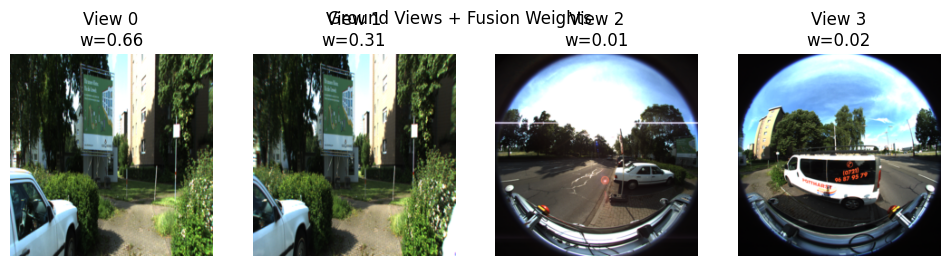

In [40]:
plt.figure(figsize=(12,3))
for i in range(4):
    plt.subplot(1,4,i+1)
    plt.imshow(views[i].permute(1,2,0))
    plt.title(f"View {i}\nw={weights[i]:.2f}")
    plt.axis("off")
plt.suptitle("Ground Views + Fusion Weights")
plt.show()


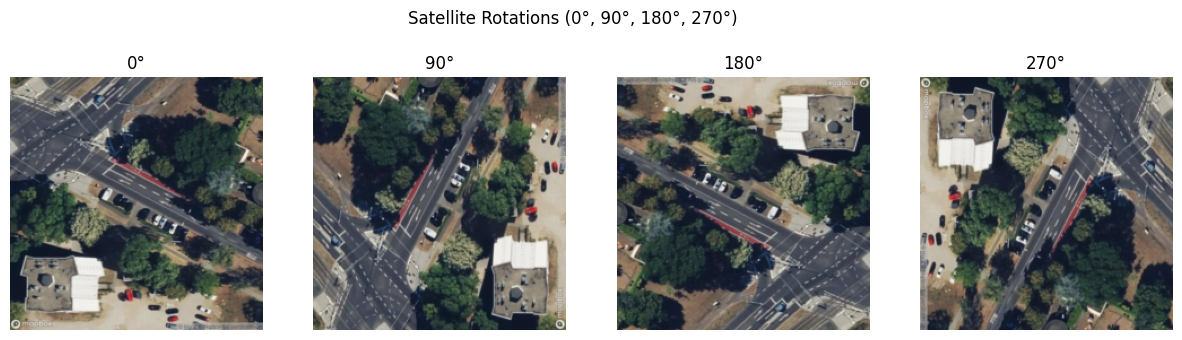

In [41]:
rotations = [0, 90, 180, 270]

plt.figure(figsize=(15,4))
for i, ang in enumerate(rotations):
    sat_rot = rotate_tensor(sat.unsqueeze(0), ang)[0]
    plt.subplot(1,4,i+1)
    plt.imshow(sat_rot.permute(1,2,0))
    plt.title(f"{ang}°")
    plt.axis("off")

plt.suptitle("Satellite Rotations (0°, 90°, 180°, 270°)")
plt.show()



Top-5 Retrieved Satellites:
Rank 1: /kaggle/input/satellite-view-kitti/satellite_050.png
Rank 2: /kaggle/input/satellite-view-kitti/satellite_052.png
Rank 3: /kaggle/input/satellite-view-kitti/satellite_045.png
Rank 4: /kaggle/input/satellite-view-kitti/satellite_053.png
Rank 5: /kaggle/input/satellite-view-kitti/satellite_048.png


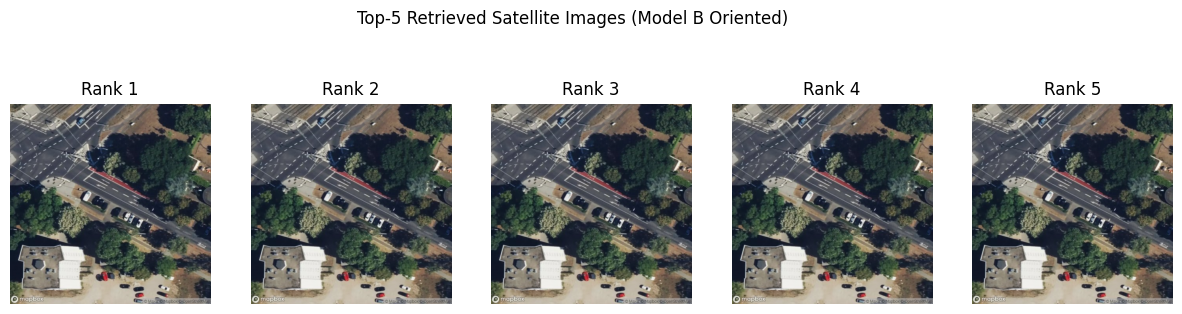

In [42]:
fused_norm = F.normalize(fused.cpu(), dim=1)

sim_scores = fused_norm @ sat_gallery_emb.T
topk_vals, topk_idx = torch.topk(sim_scores, TOP_K, dim=1)

print("\nTop-5 Retrieved Satellites:")
for rank, ind in enumerate(topk_idx[0]):
    print(f"Rank {rank+1}: {sat_gallery_paths[ind]}")

plt.figure(figsize=(15,4))
for i, ind in enumerate(topk_idx[0]):
    img = Image.open(sat_gallery_paths[ind]).convert("RGB")
    plt.subplot(1, TOP_K, i+1)
    plt.imshow(img)
    plt.title(f"Rank {i+1}")
    plt.axis("off")

plt.suptitle("Top-5 Retrieved Satellite Images (Model B Oriented)")
plt.show()
